In [ ]:
# Install Python libraries
! pip3 install numba==0.60.0
! pip3 install numpy==1.23.5
! pip3 install pandas==2.0.1
! pip3 install scipy==1.13.1
! pip3 install matplotlib==3.9.2
! pip3 install scanpy==1.9.3
! pip3 install scikit-learn==1.5.1
! pip3 install networkx==3.3.0
! pip3 install pyvis==0.3.2
! pip3 install bokeh==3.0.3
! pip3 install selenium==4.33.0
! pip3 install pyper==1.1.2

# 1. Library and settings

In [5]:
import warnings
warnings.simplefilter('ignore')

import time
from functools import wraps

import sys
import os
import threading
import pickle
import glob
import gzip

from numba import jit
import numpy as np
import pandas as pd
from scipy.sparse import csc_matrix, save_npz, load_npz

import scanpy as sc
from sklearn.preprocessing import StandardScaler
from sklearn import linear_model
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

import networkx as nx
from pyvis.network import Network

from sklearn.covariance import GraphicalLassoCV

import pyper

from bokeh.plotting import figure, show
from bokeh.io import output_notebook
from bokeh.models import ColumnDataSource, Range1d, Whisker
from bokeh.transform import linear_cmap
from bokeh.palettes import Viridis256
from bokeh.models import LinearColorMapper, ColorBar

In [2]:
os.makedirs(f'network/250615_CRP_to_Vn', exist_ok=True)
os.makedirs(f'network/250615_CRP_to_Vn/regions_for_targets', exist_ok=True)
os.makedirs(f'network/250615_CRP_to_Vn/TFs_for_targets', exist_ok=True)
os.makedirs(f'network/250615_CRP_to_Vn/pairs_for_targets', exist_ok=True)
os.makedirs(f'network/objects', exist_ok=True)

# 2. General functions

In [6]:
def logging_time(func):
    @wraps(func)
    def wrapper(*args, **kargs) :
        start = time.time()
        result = func(*args,**kargs)
        elapsed_time =  time.time() - start
        print(f'Elapsed time was {elapsed_time:.2f} sec. for the function "{func.__name__}"')
        return result
    return wrapper


def write_progress(log):
    f = open(f'progress.txt', 'a')
    f.write(f'{log}\n')
    f.close()

    
def save_time(func):
    @wraps(func)
    def wrapper(*args, **kargs) :
        start = time.time()
        result = func(*args,**kargs)
        elapsed_time =  time.time() - start
        write_progress(f'Elapsed time was {elapsed_time:.2f} sec. for the function "{func.__name__}"')
        return result
    return wrapper


@logging_time
def calc_r(x, y):
    return np.corrcoef(x, y)[0,1]


@logging_time
def save_pickle(obj, save_dir):
    with open(save_dir, mode='wb') as fh:
        pickle.dump(obj, fh)
                
        
@logging_time
def load_pickle(path):
    with open(path, "rb") as tf:
        res = pickle.load(tf)
        return res

# 3. Build chromatin coupled dynamincal GRN

## 3.1. Class

In [14]:
class SC_DATA():
    def __init__(self):
        self.data = {}
        self.total_reads = 10**4
        self.cluster_def_path = ""
        self.cdef = {}
        self.cluster_num = []
        self.df = {}
        self.df_s = {}
    
    
    ######################################
    # 1. add data
    ######################################
    @logging_time
    def add_data(self, tag, path):
        bnum = max([self.data[t]["bnum"] for t in self.data.keys()]) + 1 if len([self.data[t]["bnum"] for t in self.data.keys()]) != 0 else 1
        self.data[tag] = {"bnum": bnum, "path": path, "obj": ""}
                
    
    ######################################
    # 2-1. read data as a pandas dataframe
    ######################################
    def read_data(self):
        pass

    
    ######################################
    # 2-2. rename cell barcodes (so that they are unique across all dataset)
    ######################################
    @logging_time
    def rename_cell_barcodes(self):
        if all(["df" in self.data[t].keys() for t in self.data.keys()]):
            for tag in self.data.keys():
                self.data[tag]["df"].index = [f'{b}_{self.data[tag]["bnum"]}' for b in self.data[tag]["df"].index.tolist()]
        else:
            raise("You need to convert your sc-omics data into pandas dataframe objects before renaming cell barcodes.")

            
    ######################################
    # 3-1. filter by cluster (using cell barcodes)
    ######################################
    @logging_time
    def load_cluster_def(self, cluster_def_path):
        self.cluster_def_path = cluster_def_path # "cluster_def_by_monocle_final.v2.0.pkl"

        # get barcodes for clusters
        with open(self.cluster_def_path, "rb") as tf:
            self.cdef = pickle.load(tf)

    
    @logging_time
    def select_clusters(self, clusters):
        self.cluster_num = clusters
        for tag in self.data.keys():
            self.data[tag]["cluster"] = [self.cdef[b] if b in self.cdef.keys() else -1 for b in self.data[tag]["df"].index.tolist()]

        for tag in self.data.keys():
            tfs = [i in clusters for i in self.data[tag]["cluster"]]
            self.data[tag]["df_c"] = self.data[tag]["df"][tfs]
    
    
    ######################################
    # 3-2. combine experiments
    ######################################
    @logging_time
    def combine_dataframe(self):
        df = pd.concat([self.data[tag]["df_c"] for tag in self.data.keys()], axis=0, join='outer').fillna(0)
        self.df = df
        self.df_s = df
            
        
    ######################################
    # 3-3. replace feature names: "-" to "."
    ######################################
    @logging_time
    def replace_symbols(self):
        self.df.columns = [i.replace("-", ".") for i in self.df.columns.tolist()]
        self.df_s.columns = [i.replace("-", ".") for i in self.df_s.columns.tolist()]

        
    ######################################
    # 4. scaling
    ######################################
    @logging_time
    def reset_scaling(self):
        self.df_s = self.df
    
    
    @logging_time
    def normalization(self):
        # np array
        X = np.array(self.df_s)

        # Normalization
        s = np.sum(X, axis=1)
        s = np.array([x if x != 0 else 1 for x in s])
        X = ((self.total_reads * X).T / s).T
        
        self.df_s = pd.DataFrame(
            X,
            index=self.df.index,
            columns=self.df.columns
        )

        
    @logging_time
    def custom_log_transform(self):
        # np array
        X = np.array(self.df_s)

        # determine non-zero min value
        np.place(X, X == 0, X.max())
        df_s_min = X.min()
        
        # replacement
        X = np.array(self.df_s)
        np.place(X, X <= 0, df_s_min)
        
        # log transformation
        X = np.log(X)

        # DataFrame
        self.df_s = pd.DataFrame(
            X,
            index=self.df.index,
            columns=self.df.columns
        )
        
        
    @logging_time
    def boxcox_transformation(self):
        pass

    
    @logging_time
    def custom_standardization(self):
        # np array
        X = np.array(self.df_s)

        # determine non-zero min value
        np.place(X, X == 0, X.max())
        df_s_min = X.min()
        
        # replacement
        X = np.array(self.df_s)
        np.place(X, X <= 0, df_s_min)
        
        # standardization
        out = []
        for c in range(len(X.T)):
            arr = [i for i in X[:,c] if i > df_s_min]
            m = np.mean(arr)
            std = np.std(arr) + 10**-5
            out.append(list((X[:,c] - m) / std))
            
        self.df_s = pd.DataFrame(
            X,
            index=self.df.index,
            columns=self.df.columns
        )

In [15]:
class GEX(SC_DATA):
    def __init__(self):
        super().__init__()
                
        self.min_genes = 1000
        self.min_cells = 3
        self.n_genes = 6000
        self.percento_mito = 0.15
        
        self.data = {}
        
        
    ######################################
    # 2-1. read as a pandas dataframe
    ######################################
    @logging_time
    def read_gex(self):
        for tag in self.data.keys():
            self.data[tag]["obj"] = sc.read_10x_mtx(self.data[tag]["path"], var_names='gene_symbols', cache=True)
            

    @logging_time
    def prefiltering(self):
        for tag in self.data.keys():
            # genes and cells
            sc.pp.filter_cells(self.data[tag]["obj"], min_genes=self.min_genes)
            sc.pp.filter_genes(self.data[tag]["obj"], min_cells=self.min_cells)

            # mitochondria
            mito_genes = self.data[tag]["obj"].var_names.str.startswith('mt-')
            self.data[tag]["obj"].obs['percent_mito'] = np.sum(self.data[tag]["obj"][:, mito_genes].X, axis=1).A1 / np.sum(self.data[tag]["obj"].X, axis=1).A1
            self.data[tag]["obj"] = self.data[tag]["obj"][self.data[tag]["obj"].obs['n_genes'] < self.n_genes, :]
            self.data[tag]["obj"] = self.data[tag]["obj"][self.data[tag]["obj"].obs['percent_mito'] < self.percento_mito, :]
            
    
    @logging_time
    def convert_to_df(self):
        for tag in self.data.keys():
            self.data[tag]["df"] = pd.DataFrame(
                self.data[tag]["obj"].X.toarray(),
                index=self.data[tag]["obj"].obs.index.tolist(),
                columns=self.data[tag]["obj"].var["gene_ids"].index.tolist()
            )

    @logging_time
    def convert_to_dataframe(self):
        self.read_gex()
        self.prefiltering()
        self.convert_to_df()
        
    
    @logging_time
    def set_dataframe(self, tag, data):
        self.data[tag] = data

In [16]:
class ATAC(SC_DATA):
    def __init__(self):
        super().__init__()
        self.data = {}
        self.gtf = {}
        
    
    ######################################
    # 2-1. read as a pandas dataframe
    ######################################
    @logging_time
    def convert_to_dataframe(self):
        for tag in self.data.keys():
            self.data[tag]["df"] = pd.read_csv(self.data[tag]["path"], index_col=0).T

            
    @logging_time
    def set_dataframe(self, tag, data):
        self.data[tag] = data
                                
                                
    ######################################
    # A-1. load GTF 
    ######################################
    # Note that this method is only for mouse genome.
    @logging_time
    def load_gtf(self, path): 
        # read gzip gtf file
        with gzip.open(path, mode='rt') as f:
            data = f.readlines()        
        
        # parse gtf file
        gtf = [
            i.rstrip().split("\t")[:8] + 
            [{j.split(" ")[0]:j.replace(';','').split(" ")[1].replace('"','') for j in i.rstrip().split("\t")[8].split("; ")}]
            for i in data
            if not i.startswith("#")
        ]

        # extract exons
        d = []
        targets = [i for i in gtf if i[2] == "exon"]

        for row in targets:        
            chr_ = row[0]
            region = row[2]
            start = int(row[3])
            end = int(row[4])
            strand = row[6]
            g = row[8]["gene_id"]
            t = row[8]["transcript_id"]
            n = row[8]["gene_name"]

            # Mouse specific codes
            if chr_ in ["1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "12", "13", "14", "15", "16", "17", "18", "19"]:
                chrnum = int(chr_)
            elif chr_ in ["X"]:
                chrnum = 20
            elif chr_ in ["Y"]:
                chrnum = 21
            else:
                chrnum = 22

            d.append({
                "gene_id":g,
                "transcript_id":t,
                "region":region,
                "chr":chr_,
                "chrnum": chrnum,
                "start":start,
                "end":end,
                "strand":strand,
                "name":n
            })

        d = sorted(d, key=lambda x: (x["chrnum"], x["start"], x["end"]))
        
        # make dictionary
        d_ = {}
        for _ in d:
            if _["name"] not in d_.keys():
                d_[_["name"]] = []
            d_[_["name"]].append([_["chr"], _["start"], _["end"], _["strand"]])
    
        self.gtf = d_
        
    
    @logging_time
    def set_gtf(self, data):
        self.gtf = data

        
    ######################################
    # A-2 (1). get region (input = gene)
    ######################################
    @logging_time
    def get_region_fast(self, gene, width):
        if gene not in self.gtf.keys():
            return ["1", 1, 1]

        else:    
            res = self.gtf[gene]
            chr_ = res[0][0]
            starts = [i[1] for i in res]
            ends = [i[2] for i in res]

            if res[0][3] == "+":
                start = min(starts)
                end = max(ends)
            else:
                start = max(ends)
                end = min(starts)

            r_start = start - width // 2 - width % 2
            r_end = start + width // 2

            return [chr_, r_start, r_end]

        
    ######################################
    # A-2 (2). get region (input = coordinate)
    ######################################
    @logging_time
    def get_point_fast(self, chr_, point, width):
        r_start = point - width // 2 - width % 2
        r_end = point + width // 2
        return [chr_, r_start, r_end]

        
    ######################################
    # A-3. get peaks
    ######################################
    @logging_time
    def output_all_peaks(self, cnames, region):
        peaks = []
        for p in cnames:
            # skip genes
            s = p.split(".")
            if len(s) != 3:
                continue

            chr_ = s[0].split("chr")[1]
            if chr_ == region[0]:
                start = int(s[1])
                end = int(s[2])
                if region[1] <= start and end <= region[2]:
                    peaks.append(p)
                    
        return peaks
    
            
    @logging_time
    def pick_up_peaks(self, cnames, target, width=440000):
        # in case of gene as an input
        if len(target.split(".")) != 3:
            region = self.get_region_fast(target, width)
            out = self.output_all_peaks(cnames, region)
            return list(set(out) - set([target]))
        
        # in case of coordinate as an input
        else:
            rinfo = target.split(".")
            chr_ = rinfo[0].split("chr")[1]
            point = (int(rinfo[1]) + int(rinfo[2])) // 2
            region = self.get_point_fast(chr_, point, width)
            out = self.output_all_peaks(cnames, region)
            return list(set(out) - set([target]))

In [17]:
class Multiome_Networks():
    @logging_time
    def __init__(self, clusters, tissues):
        ######################################
        # 1. Metadata
        ######################################
        # TFs
        self.TFs = [i.rstrip() for i in open("tfs/mouse_tissue_tf_atlas.csv").readlines()[:-1]]
        

        # GTF
        # path
        bpath = "/Users/tatsu/Documents/qmer/川島研/220830_川島研_解析/221010_get_seq_from_ATAC_peak_001/src"
        path = f'{bpath}/Mus_musculus.GRCm38.102.gtf.gz'
        
        # read gzip gtf file
        with gzip.open(path, mode='rt') as f:
            data = f.readlines()        

        # parse gtf file
        gtf = [
            i.rstrip().split("\t")[:8] + 
            [{j.split(" ")[0]:j.replace(';','').split(" ")[1].replace('"','') for j in i.rstrip().split("\t")[8].split("; ")}]
            for i in data
            if not i.startswith("#")
        ]

        # extract exons
        d = []
        targets = [i for i in gtf if i[2] == "exon"]

        for row in targets:        
            chr_ = row[0]
            region = row[2]
            start = int(row[3])
            end = int(row[4])
            strand = row[6]
            g = row[8]["gene_id"]
            t = row[8]["transcript_id"]
            n = row[8]["gene_name"]

            # Mouse specific codes
            if chr_ in ["1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "12", "13", "14", "15", "16", "17", "18", "19"]:
                chrnum = int(chr_)
            elif chr_ in ["X"]:
                chrnum = 20
            elif chr_ in ["Y"]:
                chrnum = 21
            else:
                chrnum = 22

            d.append({
                "gene_id":g,
                "transcript_id":t,
                "region":region,
                "chr":chr_,
                "chrnum": chrnum,
                "start":start,
                "end":end,
                "strand":strand,
                "name":n
            })

        d = sorted(d, key=lambda x: (x["chrnum"], x["start"], x["end"]))

        # make dictionary
        d_ = {}
        for _ in d:
            # replace "-" with "."
            _["name"] = _["name"].replace("-", ".")
            if _["name"] not in d_.keys():
                d_[_["name"]] = []
            d_[_["name"]].append([_["chr"], _["start"], _["end"], _["strand"]])

        self.gtf = d_
        
        
        ######################################
        # 2. Cluster & Tissue
        ######################################
        # Cluster Map
        self.cluster_map = {
            1: "Art",
            3: "CapEC3",
            4: "CapEC2",
            5: "CapEC1",
            6: "CRP",
            7: "TrEC",
            8: "HEC",
            9: "Vn",
            -1: "11. Others"
        }
        
        # Cluster Definition
        with open(f'cluster_def_by_monocle_final.v2.1.rev.pkl', "rb") as tf:
            self.cdef = pickle.load(tf)
            
        # Target clusters
        self.clusters = clusters
                        
        # Tissue Map
        self.tissue_map = {
            "PLN": 1,
            "MLN": 2,
            "PP": 3
        }

        # Target tissues
        self.tissues = tissues
        self.tissue_n = [self.tissue_map[i] for i in tissues]
        
        
        ######################################
        # 3. Marker genes
        ######################################
        path = 'Seurat'
        whole=True
        self.markers = {"all":{}}
        
        for tissue in self.tissues:
            self.markers[tissue] = {}
            
            for cnum in self.clusters:
                cname = self.cluster_map[cnum]
                self.markers[tissue][cname] = {}
                
                path1 = f'{path}/{tissue}/out/markers.gex.v2.0.csv'
                path2 = f'{path}/out/markers.gex.{cname}.{tissue}.v2.0.csv'
                path3 = f'{path}/out/markers.gex.v2.0.csv'
                
                if os.path.exists(path1):
                    df = pd.read_csv(path1, index_col=0)
                    self.markers[tissue][cname]["one_on_others"] = df[df["cluster"]==cname]["gene"].tolist()
            
                if os.path.exists(path2):
                    df = pd.read_csv(path2, index_col=0)
                    self.markers[tissue][cname]["one_on_one"] = df.index.tolist()
                    
                if os.path.exists(path3) and whole:
                    df = pd.read_csv(path3, index_col=0)
                    self.markers["all"][cname] = df[df["cluster"]==cname]["gene"].tolist()

        if 8 in self.clusters:
            self.markers["plus"] = ["8030455M16Rik", "9130230L23Rik", "Flrt3", "Cdh8", "Nefh", "Stab2"]
               
        # Concatenate marker gene lists
        out = []
        for tissue in self.markers.keys():
            if tissue == "plus":
                out += self.markers["plus"]
                continue

            for cname in self.markers[tissue].keys():
                out += self.markers[tissue][cname]

        self.markers_ = self.markers
        self.markers = list(set(out))
        
        
    
    ######################################
    # 4-1. Functions for dataframes
    ######################################
    @logging_time
    def load_dataframe(self, exp_type, path, number=None):
        if exp_type == 'GEX':
            # load
            data = sc.read_10x_mtx(path, var_names='gene_symbols', cache=True)
            # to dataframe
            df = pd.DataFrame(
                data.X.toarray(),
                index=data.obs.index.tolist(),
                columns=data.var["gene_ids"].index.tolist()
            )
            # rename cell barcodes
            if number is not None:
                df.index = [f'{b}_{number}' for b in df.index.tolist()]
            return df

        elif exp_type == 'ATAC':
            # load
            df = pd.read_csv(path, index_col=0).T
            # rename cell barcodes
            if number is not None:
                df.index = [f'{b}_{number}' for b in df.index.tolist()]
            return df

        else:
            return None


    @logging_time
    def filter_by_cluster(self, df):
        cluster = [self.cdef[b] if b in self.cdef.keys() else -1 for b in df.index.tolist()]
        return df.loc[[i in self.clusters for i in cluster], :]


    @logging_time
    def combine_dataframe(self, dfs):
        df = pd.concat(dfs, axis=0, join='outer').fillna(0)
        df.columns = [c.replace("-", ".") for c in df.columns.tolist()]
        return df


    @logging_time
    def normalization(self, df, total_reads):
        X = np.array(df)
        s = np.sum(X, axis=1)
        s = np.array([x if x != 0 else 1 for x in s])
        X = ((total_reads * X).T / s).T        
        return pd.DataFrame(X, index=df.index, columns=df.columns)


    @logging_time
    def replace_zero(self, X):
        _X = X
        np.place(_X, _X == 0, _X.max())
        min_v = _X.min()
        np.place(X, X <= 0, min_v)
        return X


    @logging_time
    def log_transform(self, df):
        X = np.log(self.replace_zero(np.array(df)))
        return pd.DataFrame(X, index=df.index, columns=df.columns)


    @logging_time
    def standardization(self, df):
        sc = StandardScaler()
        X = self.replace_zero(np.array(df))
        sc.fit(X)
        X =sc.transform(X)
        return pd.DataFrame(X, index=df.index, columns=df.columns)


    @logging_time
    def preprocess_dataframe(self, dfs):
        _ = []
        for df in dfs:
            _.append(self.filter_by_cluster(df))

        df = self.combine_dataframe(_)
        df = self.normalization(df, 10**4)
        df = self.log_transform(df)
        df = self.standardization(df)
        
        return df
    
    
    @logging_time
    def build_dataframe(self, df_gex, df_atac):
        self.gex = df_gex
        self.atac = df_atac
        self.df = pd.concat([self.gex, self.atac], axis=1, join="inner")
        self.columns = self.df.columns.tolist()
        self.index = self.df.index.tolist()
        self.df = csc_matrix(self.df)    

        
    @logging_time
    def get_col(self, feature):
        for i in range(len(self.columns)):
            if self.columns[i] == feature:
                return self.df.getcol(i).toarray().flatten()
        return np.ones(self.df.shape[0])

    
    ######################################
    # 4-2. Functions for peaks
    ######################################
    @logging_time
    def get_region_fast(self, gene, width):
        if gene not in self.gtf.keys():
            return ["1", 1, 1]

        else:    
            res = self.gtf[gene]
            chr_ = res[0][0]
            starts = [i[1] for i in res]
            ends = [i[2] for i in res]

            if res[0][3] == "+":
                start = min(starts)
                end = max(ends)
            else:
                start = max(ends)
                end = min(starts)

            r_start = start - width // 2 - width % 2
            r_end = start + width // 2

            return [chr_, r_start, r_end]


    @logging_time
    def get_point_fast(self, chr_, point, width):
        r_start = point - width // 2 - width % 2
        r_end = point + width // 2
        return [chr_, r_start, r_end]


    @logging_time
    def output_all_peaks(self, cnames, region):
        peaks = []
        for p in cnames:
            s = p.split(".")
            if len(s) != 3:
                continue

            chr_ = s[0].split("chr")[1]
            if chr_ == region[0]:
                start = int(s[1])
                end = int(s[2])
                if region[1] <= start and end <= region[2]:
                    peaks.append(p)

        return peaks


    @logging_time
    def pick_up_peaks(self, cnames, target, width=440000):
        # in case of gene as an input
        if len(target.split(".")) != 3:
            region = self.get_region_fast(target, width)
            out = self.output_all_peaks(cnames, region)
            return list(set(out) - set([target]))

        # in case of coordinate as an input
        else:
            rinfo = target.split(".")
            chr_ = rinfo[0].split("chr")[1]
            point = (int(rinfo[1]) + int(rinfo[2])) // 2
            region = self.get_point_fast(chr_, point, width)
            out = self.output_all_peaks(cnames, region)
            return list(set(out) - set([target]))
        
    
    ######################################
    # 4-3. Functions for regression
    ######################################
    def set_base_path(self, base_path):
        self.base_path = base_path


    def set_analysis_name(self, analysis_name):
        self.analysis_name = analysis_name
        
        
    @save_time
    def init_network_analysis(self):
        # definitions
        self.xys = ["regions_for_targets", "TFs_for_targets", "pairs_for_targets"]

        # state
        self.target_genes = self.markers
        self.target_peaks = []
        
        # network data
        self.d = {}
        for j in self.xys:
            self.d[j] = {}
            self.d[j]["save_dir"] = f'{self.base_path}/{self.analysis_name}/{j}'
            self.d[j]["results"] = {}
            self.d[j]["cache"] = []
            self.d[j]["count"] = 0
        
        # stats
        self.gene_complete = 0
        self.peak_complete = 0
        self.n_regress = 0
        self.mode = "not specified"
        
                
    @save_time
    def load_cache(self):
        def get_cache(dir_name):
            return list(set([i.split("/")[-1].split(".pkl")[0] for i in glob.glob(dir_name + "/*pkl")]))
                
        # load cache
        for xy in self.d.keys():
            self.d[xy]["cache"] = get_cache(self.d[xy]["save_dir"])

            for t in self.d[xy]["cache"]:
                self.d[xy]["results"][t] = load_pickle(f'{self.d[xy]["save_dir"]}/{t}.pkl')
                    
                                        
    @save_time
    def update_cache(self, ys, xyt="regions_for_targets"):
        # abbreviation
        cache = self.d[xyt]["cache"]
        
        # update
        if len(cache) != 0:
            ys_ = list(set(ys) - set(cache))
            cache_ = list(set(cache) | set(ys))
        else:
            ys_ = ys
            cache_ = ys
            
        self.d[xyt]["cache"] = cache_
            
        # return diff
        return ys_
        
    @save_time
    def lasso(self, df_X, y, save_dir,
        n_split=5,
        alphas = 10**np.arange(-6, 1, 0.1),
        max_iter=10**3,
        n_jobs=-1
    ):
        # 1. rename etc.
        X = np.array(df_X)
        cols = df_X.columns.tolist()

        # 2-1. exclude irrelevant　features
        rs = [abs(calc_r(X[:,i], y)) for i in range(len(X.T))]
        idxes = [i for i in range(len(rs)) if not np.isnan(rs[i])]
        X = X[:, idxes]
        cols = [cols[i] for i in idxes]

        # 2-2. select top 250 relevant features
        idxes = list(np.argsort([rs[i] for i in idxes]))[::-1][:250]        
        X = X[:, idxes]
        cols = [cols[i] for i in idxes]
        print("lasso", len(cols))

        # 3-1. prepare object
        lasso_best = linear_model.LassoCV(
            cv = n_split,
            alphas = alphas,
            max_iter = max_iter,
            n_jobs = n_jobs
        )

        # 3-2. skip zero feature
        if X.shape[1] == 0:
            return {
                "r": np.nan,
                "coef": [],
                "feature": [],
                "intercept": np.nan
            }

        # 3-3. Training
        lasso_best.fit(X, y)

        # 4. results
        y_pred = lasso_best.predict(X)
        corr = calc_r(y, y_pred)
        coef = lasso_best.coef_

        save_pickle(lasso_best, save_dir)

        intercept = lasso_best.intercept_
        print("r", corr)
        return {
            "r": corr,
            "feature": cols,
            "coef": coef,
            "intercept": intercept
        }
        return        
        
                
    @save_time
    def feature_selection(
        self, ys,
        xyt="regions_for_targets",
        ntype="gene",
        parent=None,
        verbose=True
    ):
        # comments
        # rt: regression type: lasso, zipath, etc...
        # xyt: xy type: regions_for_targets, TFs_for_targets, pairs_for_targets, etc...

        # 0. count for repeat
        self.d[xyt]["count"] += 1

        # 1-1. stdout
        if verbose:
            n_repeat = self.d[xyt]["count"]
            write_progress(f'>>>> [n_repeat: {n_repeat} ({self.mode})]: {xyt} START')
            # print(f'>>>> [n_repeat: {n_repeat} ({self.mode})]: {xyt} START')
        # 1-2. exclude calculated targets
        ys_ = self.update_cache(ys, xyt=xyt)
        # 1-3. test if repeats ends
        if verbose:
            write_progress(f'{len(ys_)} out of {len(ys)} targets will be passed to the feature selection.')
            # print(f'{len(ys_)} out of {len(ys)} targets will be passed to the feature selection.\n')
        if len(ys_) == 0:
            return None
        
                
        # 4. regress
        # t0 = time.time()
        for i, y_ in enumerate(ys_):
            # if (i + 1) % 10 == 0:
            #     th = time.time()
            #     write_progress(f'{i + 1}th completed. Elapsed time was {th - t0:.1f} sec.')
            
            # 4-1. x features
            if xyt == "regions_for_targets":
                xs = [[p] for p in self.pick_up_peaks(self.columns, y_)]
            elif xyt == "TFs_for_targets":
                xs = [[tf.replace("-", ".")] for tf in self.TFs if tf.replace("-", ".") != parent]
            elif xyt == "pairs_for_targets":
                xs = []
                data = self.d["regions_for_targets"]["results"][y_]
                regions = [data["feature"][i] for i in range(len(data["feature"])) if data["coef"][i] != 0]
                for r in regions:
                    xs.extend([[r,t] for t in  self.d["TFs_for_targets"]["results"][r]["feature"]])
                    
            # 4-2. x dataframe
            out = []
            for pair in xs:
                v = np.ones(self.df.shape[0])
                for c in pair:
                    v = v * np.array(self.get_col(c))
                out.append(list(v))

            index_name = ['..'.join(p) for p in xs]
            df_X = pd.DataFrame(out, index=index_name, columns=self.index).T
            
            # 4-3. y
            y = self.get_col(y_)
            
            # 4-4. regress
            save_dir = f'{self.d[xyt]["save_dir"]}/{y_}.lasso'
            res = self.lasso(df_X, y, save_dir)
                            
            # 4-5. save
            self.d[xyt]["results"][y_] = res            
            save_pickle(res, f'{self.d[xyt]["save_dir"]}/{y_}.pkl')

        
    @save_time
    def get_peaks(self, targets, xyt="regions_for_targets"):
        outs = []
        for t in targets:
            features = [f for i, f in enumerate(self.d[xyt]["results"][t]["feature"]) if self.d[xyt]["results"][t]["coef"][i] != 0]
            outs.extend(features)            
        return list(set(outs))
    

    @save_time
    def get_pair(self, targets, i, xyt="pairs_for_targets"):
        outs = []
        for t in targets:
            pairs = [f for i, f in enumerate(self.d[xyt]["results"][t]["feature"]) if self.d[xyt]["results"][t]["coef"][i] != 0]
            
            for pair in pairs:
                c = pair.split("..")[i]
                outs.append(c)
            
        return list(set(outs))
    
   
    @save_time
    def get_all_regions(self, xyt="pairs_for_targets"):
        flist = glob.glob(f'{self.base_path}/{self.analysis_name}/{xyt}/*.pkl')
        out = []
        for path in flist:
            out.extend([f.split("..")[0] for f in load_pickle(path)["feature"]])

        return list(set(out))


    @save_time
    def construct_network_for_genes(self):
        self.mode = "gene"
        # search regions for each gene
        self.feature_selection(self.target_genes, xyt="regions_for_targets", ntype="gene")
        # search TFs for each peak
        peaks = self.get_peaks(self.target_genes)
        self.feature_selection(peaks, xyt="TFs_for_targets", ntype="gene")
        # search peak-TF pairs for genes
        self.feature_selection(self.target_genes, xyt="pairs_for_targets", ntype="gene")
        # repeat
        self.target_genes_ = self.get_pair(self.target_genes, 1)
        if len(list(set(self.target_genes_) - set(self.target_genes))) == 0:
            return None
        else:
            self.target_genes = self.target_genes_
        self.construct_network_for_genes()


    @save_time
    def construct_network_for_peaks(self):
        self.mode = "region"
        # search regions for each region
        self.feature_selection(self.target_peaks, xyt="regions_for_targets", ntype="peak")
        # search TFs for each region
        peaks = self.get_peaks(self.target_peaks)
        self.feature_selection(peaks, xyt="TFs_for_targets", ntype="peak")
        # search regions-TF pairs for each region
        self.feature_selection(self.target_peaks, xyt="pairs_for_targets", ntype="peak")
        # repeat (TFs)
        self.target_genes_ = self.get_pair(self.target_peaks, 1)
        self.target_peaks_ = self.get_pair(self.target_peaks, 0)
        gene_diff = len(list(set(self.target_genes_) - set(self.target_genes)))
        peak_diff = len(list(set(self.target_peaks_) - set(self.target_peaks)))
        if gene_diff == 0 and peak_diff == 0:
            return None
        else:
            self.target_genes = self.target_genes_
            self.target_peaks = self.target_peaks_
        self.construct_network_for_genes()
        self.construct_network_for_peaks()

## 3.2. Plot R distributions

In [8]:
def plot_r_distribution(mn):
    for j in mn.xys:
        keys = list(mn.d[j]["results"].keys())                
        keys_region = [k for k in keys if k.startswith("chr")]
        keys_gene = list(set(keys) - set(keys_region))

        if len(keys_gene) != 0:                    
            try:
                out_r = [mn.d[j]["results"][t]["r"] for t in keys_gene if not np.isnan(mn.d[j]["results"][t]["r"])]
                out_n = [len(mn.d[j]["results"][t]["feature"]) for t in keys_gene]

                print("#### Genes ####")
                plt.hist(out_r, bins=50)
                plt.title(f'xy-type={j}, type=gene, n={len(out_r)}')
                plt.show()                

                plt.hist(out_n, bins=50)
                plt.title(f'xy-type={j}, type=gene, n={len(out_n)}')
                plt.show()

            except:
                pass

        if len(keys_region) != 0:
            try:
                out_r = [mn.d[j]["results"][t]["r"] for t in keys_region if not np.isnan(mn.d[j]["results"][t]["r"])]
                out_n = [len(mn.d[j]["results"][t]["feature"]) for t in keys_region]

                print("#### Peaks ####")
                plt.hist(out_r, bins=50)
                plt.title(f'xy-type={j}, type=peak, n={len(out_r)}')
                plt.show()                

                plt.hist(out_n, bins=50)
                plt.title(f'xy-type={j}, type=peak, n={len(out_n)}')
                plt.show()
            except:
                pass

## 3.3. Visualize chromatin coupled dynamical GRN

In [11]:
def set_target_tissue(self, target_tissues):
    self.mn_target_tissues = target_tissues
    self.mn_target_tissues_n = [self.mn_tissue_name_to_num[tt] for tt in target_tissues]


def set_target_cluster_nums(self, cnum):
    self.mn_target_cluster_nums = cnum


def set_network_file_name(self, fn):
    self.mn_network_file_name = fn


def get_tissue_idxes(mn):
    return [i for i, b in enumerate(mn.index) if int(b[-1]) in mn.tissue_n and mn.cdef[b] in mn.clusters]


@save_time
def define_relations(mn):
    # pick up all relations
    mn.relations = []
    for t in mn.d["pairs_for_targets"]["results"].keys():

        # skip region
        if len(t.split(".")) == 3:
            continue

        # edge list and weights
        for i, feature in enumerate(mn.d["pairs_for_targets"]["results"][t]["feature"]):                
            peak = feature.split("..")[0]
            TF = feature.split("..")[1]
            if t == TF and not autocrine:
                continue
            coef = mn.d["pairs_for_targets"]["results"][t]["coef"][i]
            mn.relations.append([t, TF, peak, coef])

    write_progress(f'# of all relations: {len(mn.relations)}')    
    return mn


@save_time
def filter_relations(mn):
    # select core relations
    res_subset = mn.relations
    res_set = set(mn.markers)
    news = [i[1] for i in res_subset if i[0] in list(res_set)]
    res_set_ = res_set | set(news)
    while sorted(list(res_set)) != sorted(list(res_set_)):
        res_set = res_set_
        news = [i[1] for i in res_subset if i[0] in list(res_set)]
        res_set_ = res_set | set(news)

    mn.relations = [i for i in res_subset if i[0] in list(res_set)]
    
    write_progress(f'# of selected relations: {len(mn.relations)}')
    return mn


@save_time
def calc_edge_score(mn):
    dic = {}
    for l in mn.relations:
        target = l[0]
        source = l[1]
        peak = l[2]
        coef = l[3]

        edge_name = target + ".." + source

        if edge_name not in dic:
            dic[edge_name] = 0

        peak_intensity = np.mean([np.log10(i + 1) for i in np.array(mn.get_col(peak))[get_tissue_idxes(mn)]])
        expression = np.mean([np.log10(i + 1) for i in np.array(self.get_col(source))[get_tissue_idxes(mn)]])
        if expression_bias:
            if intensity_bias:
                edge_weight = peak_intensity * expression * coef
            else:
                edge_weight = expression * coef
        else:
            if intensity_bias:
                edge_weight = peak_intensity * coef
            else:
                edge_weight = coef
        dic[edge_name] += edge_weight
        
    return dic


@save_time
def define_edges(mn, edge_score_dict):
    mn.edges = []
    for en in edge_score_dict.keys():
        target = en.split("..")[0]
        source = en.split("..")[1]
        score = abs(edge_score_dict[en])
        color = "blue" if edge_score_dict[en] >=0 else "red"
        # color = "red" if edge_score_dict[en] >=0 else "blue"
        mn.edges.append([target, source, score, color])

    write_progress(f'# of edges: {len(mn.edges)}')
    return mn


@save_time
def define_nodes(mn, reds=[], blues=[], greens=[], oranges=[], node_coefs=1, node_size='default'):
    # size and color
    mn.nodes = []
    glist = list(set(np.array([[l[0], l[1]] for l in mn.edges]).flatten()))

    for g in glist:
        # size
        if node_size == 'default':
            size = 20
        elif node_size == 'expression':
            size = np.mean([np.log10(i + 1) for i in np.array(mn.get_col(g))[mn.get_tissue_idxes(mn)]]) * node_coefs

        # color
        color = "gray"
        if g in greens:
            color = 'green'
        if g in reds:
            color = "red"
        if g in blues:
            color = "blue"
        if g in orange:
            color = "orange"
        mn.nodes.append([g, size, color])
        
    return mn


@save_time
def remove_trivial_edges(mn, expression_cutoff, edge_score_cutoff, autocrine=False, positive_list=[]):
    edges = []
    for edge in mn.edges:
        target = edge[0]
        source = edge[1]
        score = edge[2]
        color = edge[3]
        
        # Positive list
        if target in positive_list or source in positive_list:
            edges.append([target, source, score, color])
            continue

        # Filter autocrine
        if target == source and not autocrine:
            continue

        # Filter by expression
        if mn.nodes[target]["expression"] < expression_cutoff or mn.nodes[source]["expression"] < expression_cutoff:
            continue

        # filter by edge score
        if abs(score) < edge_score_cutoff:
            continue

        # add edges
        edges.append([target, source, score, color])

    mn.edges = edges
    write_progress(f'# of survived edges: {len(mn.edges)}')
    return mn
    

@save_time
def remove_isolated_edges(mn, n_edge_cutoff=1, positive_list=[]):            
    # Remove nodes with a low number of edges
    negative_nodes = []
    nodes = list(set([l[0] for l in mn.edges] + [l[1] for l in mn.edges]))
    for node in nodes:
        if node in positive_list:
            continue
        cnt1 = len([g for g in [l[0] for l in mn.edges] if g == node])
        cnt2 = len([g for g in [l[1] for l in mn.edges] if g == node])
        cnt = cnt1 + cnt2
        if cnt <= n_edge_cutoff:
            negative_nodes.append(node)
    edges = []
    for edge in mn.edges:
        if edge[0] in negative_nodes or edge[1] in negative_nodes:
            continue
        edges.append(edge)
    mn.edges = edges
    write_progress(f'# of non-isolated edges: {len(mn.edges)}')
    return mn


@save_time
def graphical_lasso(mn, genes, tissues, clusters, cutoff=0.2):
    # Make matrix
    idxes = mn.index
    tissue_idxes = [i for i, idx in enumerate(idxes) if int(idx[-1]) in tissues]
    cluster_idxes = [i for i, idx in enumerate(idxes) if mn.cdef[idx] in clusters]
    idxes = sorted(list(set(tissue_idxes) & set(cluster_idxes)))
    X = []
    for gene in genes:
        X.append(list(mn.get_col(gene)[idxes]))
    X = np.array(X).T

    # GraphicalLassoCV
    model = GraphicalLassoCV(alphas=4, cv=5)
    model.fit(X)

    # Σ
    covariance_matrix = model.covariance_

    # Σ -> R
    diagonal = np.sqrt(covariance_matrix.diagonal())
    correlation_matrix = ((covariance_matrix.T / diagonal).T) / diagonal

    # Generate matrix for visualization of graph
    correlation_matrix_diag_zero = correlation_matrix - np.diag(np.diag(correlation_matrix) )
    df_grahp_data = pd.DataFrame(index=genes, columns=genes, data=correlation_matrix_diag_zero.tolist())

    negative_list = []
    for i in range(len(df_grahp_data)):
        for j in range(i + 1, len(df_grahp_data)):
            if abs(df_grahp_data.iloc[i, j]) < cutoff:
                negative_list.append([genes[i], genes[j]])

    return negative_list


@save_time
def remove_apparent_edges(mn, cutoff=None, positive_list=[]):
    if cutoff is not None:
        genes = list(set([l[0] for l in mn.edges]) | set([l[1] for l in mn.edges]))
        gl_neg_list = graphical_lasso(mn, genes, mn.tissues, mn.clusters, cutoff=cutoff)
    
        edges = []
        for edge in mn.edges:
            target = edge[0]
            source = edge[1]
            score = edge[2]
            color = edge[3]

            # Positive list
            if target in positive_list or source in positive_list:
                edges.append([target, source, score, color])
                continue

            # filter by graphical lasso
            if target != source:
                if [target, source] in gl_neg_list or [source, target] in gl_neg_list:
                    continue

            # add edges
            edges.append([target, source, score, color])

        mn.edges = edges
        write_progress(f'# of non-apparent edges: {len(mn.edges)}')
    
    return mn


@save_time
def update_nodes(mn, reds=[], blues=[], greens=[], oranges=[], node_size='default'):
    nodes_list = []
    for edge in mn.edges:
        nodes_list.extend([edge[0], edge[1]])
    nodes_list = list(set(nodes_list))
    mn.nodes = [l for l in mn.nodes if l[0] in nodes_list]
    return mn
    
    
@save_time
def add_custome_settings(mn, edge_coefs, edge_max_size):
    edges = []
    for edge in mn.edges:
        target = edge[0]
        source = edge[1]
        score = edge[2]
        color = edge[3]

        # score
        score = min(score * edge_coefs, edge_max_size)

        # color
        if source == 'Esrrg':
            if target in ['Madcam1', 'Robo2', 'Stra6']:
                color = 'red'
            elif target in ['Chst4', 'Fut7', 'Gcnt1', 'Glycam1', 'Csmd1', 'Clu', 'Ttn', 'Ndst3', 'Robo1', 'Sulf1', 'Ccl21a']:
                color = 'blue'
            else:
                color = 'red'

        # add edges
        edges.append([target, source, score_, color])

    mn.edges = edges
    # mn.edges.append(['Ar', 'Chst4', 2.5, 'red'])
    return mn
    
    

def make_network_obj(mn,
    self, prefix, edge_score_cutoff, expression_cutoff,
    edge_default_size = 1,
    edge_coefs = 1,
    edge_max_size = 5,
    node_default_size = 10,
    node_coefs = 10,
    node_exp_coef = 10,
    n_edge_cutoff=2,
    customized_node=False,
    autocrine=False,
    gl_cutoff=None,
    gl_tissues=[1, 2, 3],
    gl_clusters=[7, 8, 9, 10],
    gl_pos_list=['Chst4'],
    d=None
):
    # make dataframe
    df_edges = pd.DataFrame(mn.edges, columns=["target", "source", "weight", "color"])
    df_nodes = pd.DataFrame(mn.nodes, columns=["node", "color", "size"])
    node_attr_dic = df_nodes.set_index("node").to_dict(orient="index")

    # network
    G = nx.from_pandas_edgelist(df_edges, source="source", target="target", edge_attr=True, create_using=nx.DiGraph())
    nx.set_node_attributes(G, node_attr_dic)
    pyvis_G = Network(notebook=True)
    pyvis_G.from_nx(G)
    pyvis_G.show_buttons(True)

    tissue_names = self.mn_target_tissues
    cluster_names = "-".join([str(i) for i in self.mn_target_cluster_nums])        

    pyvis_G.show(
        f'{mn.base_path}/{mn.analysis_name}/{prefix}_{tissue_names}_{cluster_names}_{self.mn_network_file_name}.html'
    )
    return G, df_edges, df_nodes

## 3.4. Train chromatin coupled dynamical GRN

In [ ]:
mn = Multiome_Networks()

# 1. experiment data path
# GEX
mn.add_data("GEX", "PLN", "PLN/filtered_feature_bc_matrix/")
mn.add_data("GEX", "MLN", "MLN/filtered_feature_bc_matrix/")
mn.add_data("GEX", "PP", "PP/filtered_feature_bc_matrix/")
# ATAC
mn.add_data("ATAC", "PLN", "peak_table_PLN.csv")
mn.add_data("ATAC", "MLN", "peak_table_MLN.csv")
mn.add_data("ATAC", "PP", "peak_table_PP.csv")

# 2. organism-specific data path
bpath = "../../221010_get_seq_from_ATAC_peak_001/src"
mn.set_genome_path(f'{bpath}/Mus_musculus.GRCm38.dna.primary_assembly.fa')
mn.set_gtf_path(f'{bpath}/Mus_musculus.GRCm38.102.gtf.gz')
mn.set_TFs_path("tfs/mouse_tissue_tf_atlas.csv")

# 3. User-annotated data (cluster definition)
mn.define_cluster_num_to_name()
mn.set_cluster_def_version("2.0")
mn.set_base_path("network_analysis_multiome")
mn.set_analysis_name("230506_CRP_to_Vn")

# 4. User-annotated data (marker definition)
mn.define_tissue_name_to_num()
mn.set_original_tissue_list(["PLN", "MLN", "PP"])
mn.set_original_cluster_nums([7, 8, 9, 10])
mn.set_marker_path("Seurat")

# 5. compile experiment data with above info
mn.compile_data()

# 6. Network analysis  
markers = mn.flatten_marker()
mn.set_target_genes(markers)
mn.init_network_analysis()
mn.construct_network_for_genes()
mn.gene_complete = 0
mn.target_peaks = mn.get_all_regions()
mn.construct_network_for_peaks()

# 7. save object
save_pickle(mn, f'network_analysis_multiome/230506_CRP_to_Vn/230805_lasso_results.pkl')

In [18]:
mn = load_pickle("../network_analysis_multiome/230506_CRP_to_Vn/230805_lasso_results.pkl")

Elapsed time was 20.73 sec. for the function "load_pickle"


## 3.5. Performance

#### Genes ####


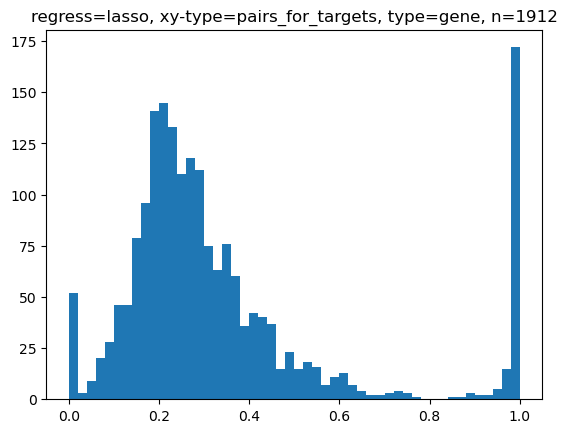

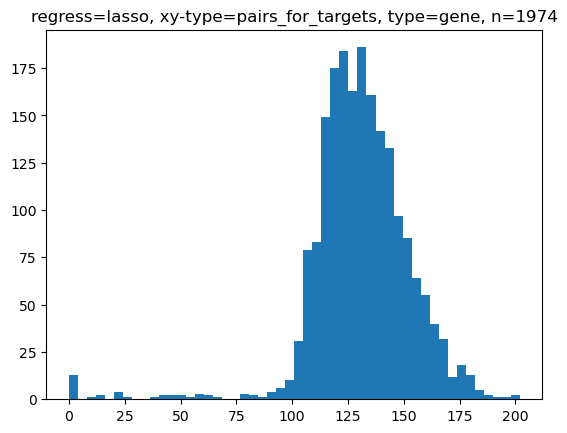

#### Peaks ####


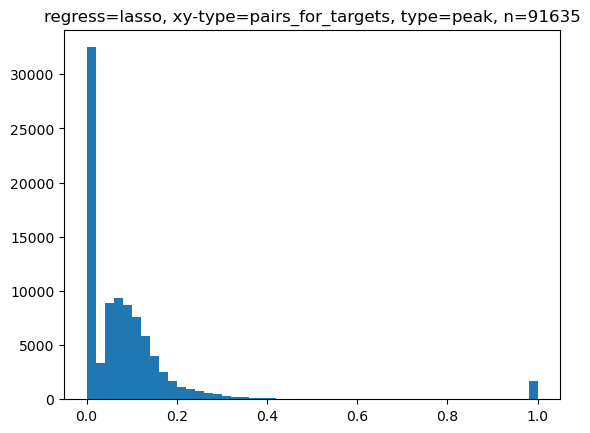

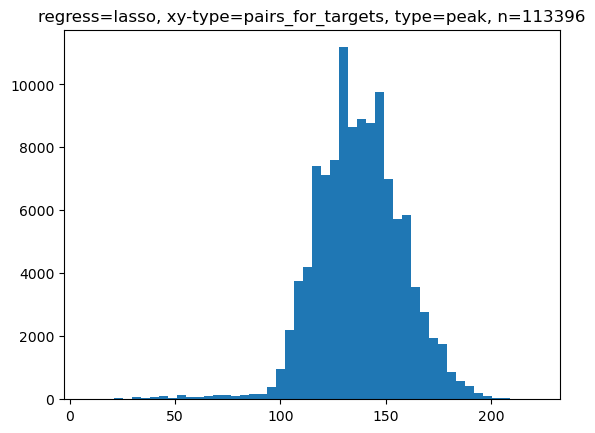

#### Genes ####


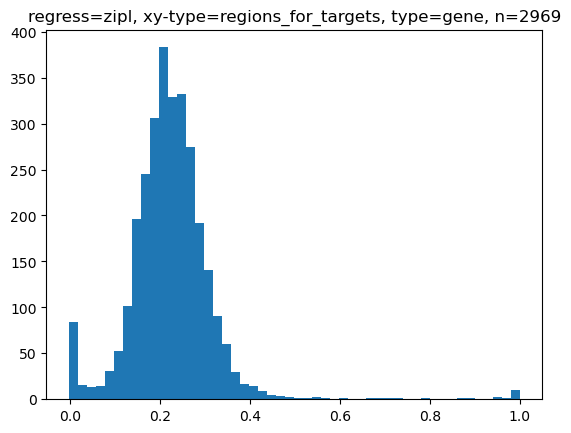

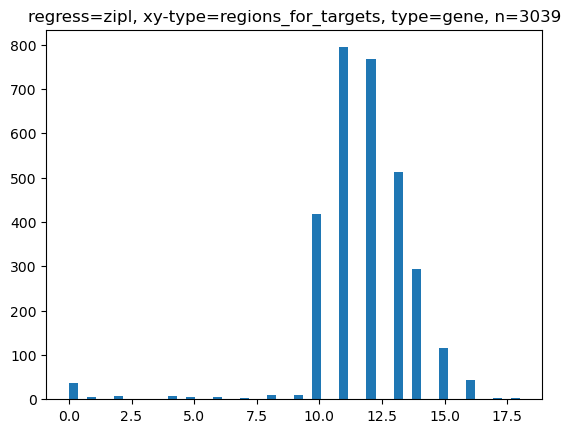

#### Peaks ####


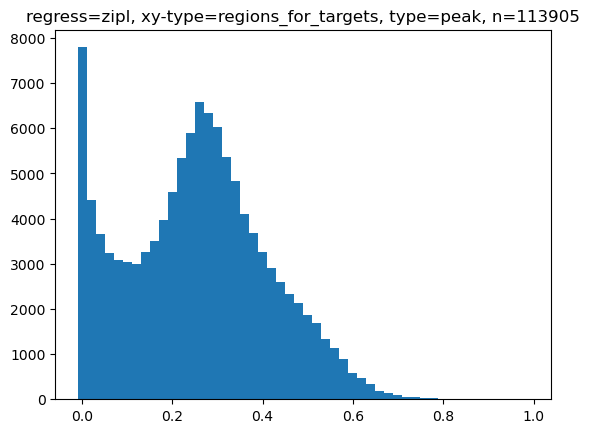

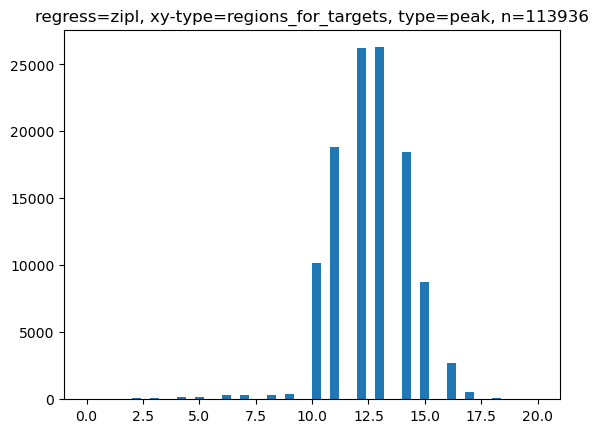

#### Peaks ####


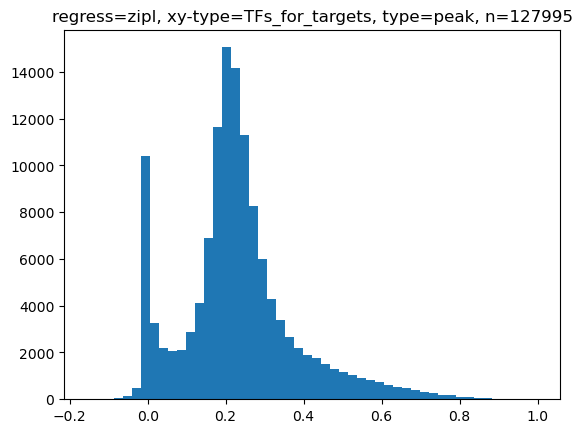

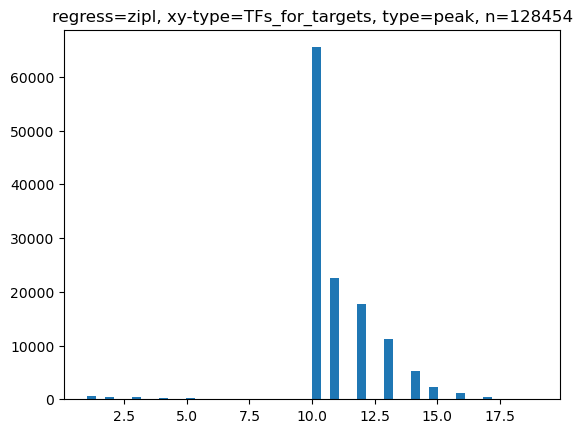

#### Genes ####


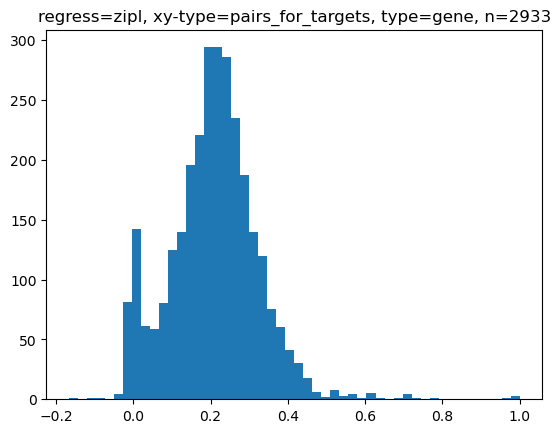

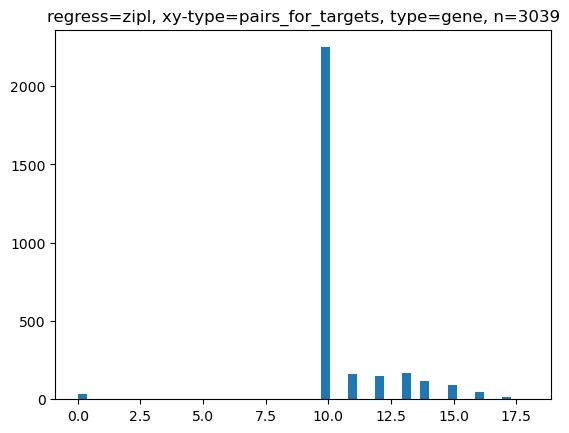

#### Peaks ####


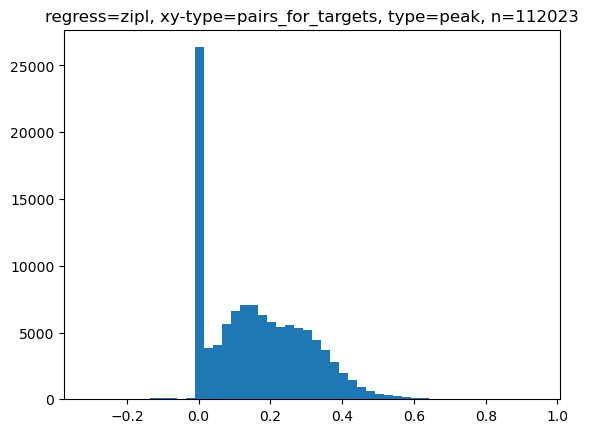

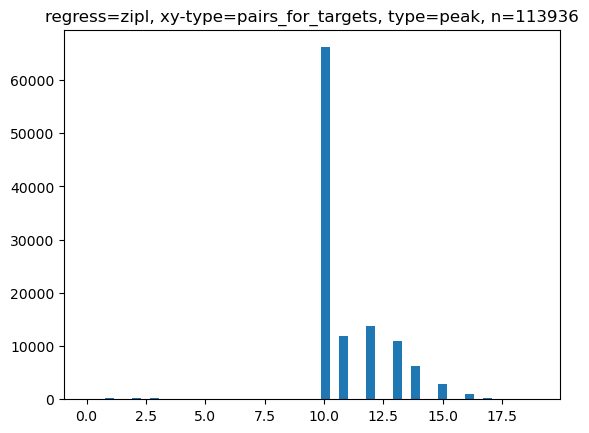

In [19]:
mn.plot_r_distribution()

## 3.6. Visualize chromatin coupled dynamical GRN as directed graph

In [ ]:
mn_all_peak_auto = load_pickle("network_analysis_multiome/230506_CRP_to_Vn/230805_lasso_results.pkl")
mn_all_peak_auto.set_target_genes(["Chst4", "Madcam1", "Fut7", "Gcnt1", "Glycam1", "Csmd1", "Clu", "Ttn", "Serpinle", "Ndst3", "Robo1", "Robo2", "Sulf1", "Ccl21a", "Stra6"])
mn_all_peak_auto.set_target_tissue(["PLN", "MLN", "PP"])
mn_all_peak_auto.set_target_cluster_nums([7, 8, 9, 10])
mn_all_peak_auto.set_network_file_name("Marker_genes")

mn_all_peak_auto.calc_edge_for_genes(expression_bias=False, intensity_bias=True, autocrine=True)
mn_all_peak_auto.calc_node()
mn_new = Multiome_Networks()
mn_all_peak_auto.make_network_obj = mn_new.make_network_obj
G = mn_all_peak_auto.make_network_obj(
    "Fig4(c)", 0.00005, 0.001, edge_coefs = 1000, edge_max_size=5,
    customized_node=True,
    autocrine=False,
    graphical_lasso_cutoff=0.2, graphical_lasso_tissues=[1, 2, 3], graphical_lasso_clusters=[7, 8, 9, 10],
    d = mn_all_peak_auto
)
G[1][['source', 'target']].to_csv('fvs/networks/Fig4(c).csv', index=False)

# 4. Calculate velocity

In [52]:
marker_pln = []
for k in mn.mn_markers['PLN'].keys():
    marker_pln += mn.mn_markers['PLN'][k]['one_on_others']
    if 'one_on_one' in mn.mn_markers['PLN'][k].keys():
        marker_pln += mn.mn_markers['PLN'][k]['one_on_one']

marker_pln = list(set(marker_pln))

In [53]:
marker_pp = []
for k in mn.mn_markers['PP'].keys():
    marker_pp += mn.mn_markers['PP'][k]['one_on_others']
    if 'one_on_one' in mn.mn_markers['PP'][k].keys():
        marker_pp += mn.mn_markers['PP'][k]['one_on_one']

marker_pp = list(set(marker_pp))

In [56]:
marker_mln = list(set(marker_pln) & set(marker_pp))

In [57]:
len(marker_pln), len(marker_pp), len(marker_mln)

(6433, 2813, 2026)

In [30]:
mn.sdf_columns

['Xkr4',
 'Gm37381',
 'Rp1',
 'Sox17',
 'Gm37587',
 'Gm37323',
 'Mrpl15',
 'Lypla1',
 'Tcea1',
 'Rgs20',
 'Atp6v1h',
 'Rb1cc1',
 '4732440D04Rik',
 'Alkal1',
 'St18',
 'Pcmtd1',
 'Gm26901',
 'Sntg1',
 'Rrs1',
 'Adhfe1',
 '2610203C22Rik',
 'Vxn',
 'Mybl1',
 'Vcpip1',
 '1700034P13Rik',
 'Sgk3',
 'Mcmdc2',
 'Snhg6',
 'Tcf24',
 'Ppp1r42',
 'Gm15818',
 'Cops5',
 'Cspp1',
 'Arfgef1',
 'Cpa6',
 'Prex2',
 'A830018L16Rik',
 'Sulf1',
 'Slco5a1',
 'Prdm14',
 'Ncoa2',
 'Gm29570',
 'Tram1',
 'Lactb2',
 'Eya1',
 'Gm9947',
 'Msc',
 'Kcnb2',
 'Terf1',
 'Sbspon',
 '4930444P10Rik',
 'Rpl7',
 'Rdh10',
 'Gm28095',
 'Stau2',
 'Gm7568',
 'Ube2w',
 'Eloc',
 'D030040B21Rik',
 'Tmem70',
 'Ly96',
 'Gm28376',
 'Jph1',
 'Pi15',
 'Gm28154',
 'Gm16070',
 'Crispld1',
 'Gm28153',
 'Gm28756',
 'Tfap2d',
 'Pkhd1',
 '4930486I03Rik',
 'Il17f',
 'Mcm3',
 '6720483E21Rik',
 'Paqr8',
 'Efhc1',
 'Tram2',
 'Tmem14a',
 'Gsta3',
 'Gm28836',
 'Kcnq5',
 'Rims1',
 'Gm29506',
 'Gm27028',
 'Gm29107',
 'Ogfrl1',
 'B3gat2',
 'Smap1',
 '

In [43]:
mn.sdf.getcol(0).toarray().shape

(5604, 1)

In [33]:
dir(mn.sdf.getcol(0))

['A',
 'H',
 'T',
 '__abs__',
 '__add__',
 '__array_priority__',
 '__bool__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__div__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__idiv__',
 '__imul__',
 '__init__',
 '__init_subclass__',
 '__isub__',
 '__iter__',
 '__itruediv__',
 '__le__',
 '__len__',
 '__lt__',
 '__matmul__',
 '__module__',
 '__mul__',
 '__ne__',
 '__neg__',
 '__new__',
 '__nonzero__',
 '__pow__',
 '__radd__',
 '__rdiv__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__rmatmul__',
 '__rmul__',
 '__round__',
 '__rsub__',
 '__rtruediv__',
 '__setattr__',
 '__setitem__',
 '__sizeof__',
 '__str__',
 '__sub__',
 '__subclasshook__',
 '__truediv__',
 '__weakref__',
 '_add_dense',
 '_add_sparse',
 '_arg_min_or_max',
 '_arg_min_or_max_axis',
 '_ascontainer',
 '_asfptype',
 '_asindices',
 '_binopt',
 '_bsr_container',
 '_container',
 '_coo_container',
 '_csc_container